# Human Activity Recognition Using Hidden Markov Models
**Activities:** Still | Standing | Walking | Jumping  
**Sensors:** Accelerometer (ax, ay, az, aT)  
**Implementation:** HMM from scratch (Baum-Welch + Viterbi)

## STEP 1 — Install Dependencies

In [2]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn -q
print('All packages ready')

All packages ready


## STEP 2 — Upload Your CSV Files

### Option A: Upload directly (simple)
Run the cell below — a file picker appears — select ALL your CSV files at once (hold Ctrl/Cmd).

### Option B: Google Drive (easier for many files)
Uncomment the Google Drive cell instead.

In [3]:
# import os

# try:
#     from google.colab import files as colab_files
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False

# DATA_DIR = 'data/'
# os.makedirs(DATA_DIR, exist_ok=True)

# if IN_COLAB:
#     print('Select ALL your CSV files in the file picker...')
#     uploaded = colab_files.upload()
#     for fname, content in uploaded.items():
#         with open(os.path.join(DATA_DIR, fname), 'wb') as f:
#             f.write(content)
#     print(f'{len(uploaded)} files uploaded to {DATA_DIR}')
# else:
#     print('Running locally — place your CSV files in the data/ folder')

In [24]:
from google.colab import drive
import shutil, glob
import os

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/HMM_Data'
os.makedirs(DATA_DIR, exist_ok=True)

DRIVE_FOLDER = '/content/drive/MyDrive/HMM_Data'  # change to your folder
for f in glob.glob(os.path.join(DRIVE_FOLDER, '*.csv')):
    shutil.copy(f, DATA_DIR)
    print(f'Copied: {os.path.basename(f)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP 3 — Imports & Configuration

In [25]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURATION  — only change things here
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAMPLING_RATE = 100    # Hz
WINDOW_SIZE   = 100    # samples (= 1 second)
STEP_SIZE     = 50     # 50% overlap
N_STATES      = 4
N_ITER        = 100
CONV_THRESH   = 1e-4
TEST_FILES    = 2      # files per activity held out for testing

# ADD keywords here if your teammate uses different file names
ACTIVITY_KEYWORDS = {
    'Still'   : ['still', 'stationary', 'static', 'rest'],
    'Standing': ['standing', 'stand'],
    'Walking' : ['walking', 'walk'],
    'Jumping' : ['jumping', 'jump'],
}

ACTIVITIES = list(ACTIVITY_KEYWORDS.keys())
STATE_MAP  = {a: i for i, a in enumerate(ACTIVITIES)}
COLORS     = ['#2196F3','#4CAF50','#FF9800','#E91E63']

print('Configuration loaded')
print(f'Window: {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f}s  |  Step: {STEP_SIZE} samples = {STEP_SIZE/SAMPLING_RATE:.1f}s')

Configuration loaded
Window: 100 samples = 1.0s  |  Step: 50 samples = 0.5s


## STEP 4 — Auto-Detect & Load All CSV Files

The notebook **automatically scans `data/`** and assigns each file to an activity based on its filename.  
**Just upload more files and rerun from this cell** — no other changes needed.

In [26]:
def detect_activity(filename):
    fname_lower = filename.lower()
    for activity, keywords in ACTIVITY_KEYWORDS.items():
        if any(kw in fname_lower for kw in keywords):
            return activity
    return None

def load_and_resample(filepath, target_rate=SAMPLING_RATE):
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]
    rename = {}
    for c in df.columns:
        cl = c.lower()
        if 'time' in cl:                          rename[c] = 'time'
        elif cl.startswith('ax'):                 rename[c] = 'ax'
        elif cl.startswith('ay'):                 rename[c] = 'ay'
        elif cl.startswith('az'):                 rename[c] = 'az'
        elif cl.startswith('at') or 'total' in cl: rename[c] = 'aT'
    df = df.rename(columns=rename)
    available = [c for c in ['time','ax','ay','az','aT'] if c in df.columns]
    df = df[available].dropna()
    if 'aT' not in df.columns:
        df['aT'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    t_uniform = np.arange(df['time'].iloc[0], df['time'].iloc[-1], 1.0/target_rate)
    out = pd.DataFrame({'time': t_uniform})
    for col in ['ax','ay','az','aT']:
        out[col] = np.interp(t_uniform, df['time'].values, df[col].values)
    return out

# Scan and load
all_csvs = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
raw_data = {act: [] for act in ACTIVITIES}
unrecognised = []

for path in all_csvs:
    fname    = os.path.basename(path)
    activity = detect_activity(fname)
    if activity:
        df = load_and_resample(path)
        raw_data[activity].append(df)
        print(f'  [{activity:10s}]  {fname:40s}  {len(df):5d} samples  ({df["time"].max():.1f}s)')
    else:
        unrecognised.append(fname)

print('\nFiles per activity:')
for act in ACTIVITIES:
    dur = sum(df['time'].max() for df in raw_data[act])
    print(f'  {act:10s}: {len(raw_data[act]):2d} files  |  {dur:.1f}s total')

if unrecognised:
    print(f'\nUnrecognised files (add keywords to ACTIVITY_KEYWORDS to include):')
    for f in unrecognised: print(f'  {f}')

  [Jumping   ]  Jumping_2.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_3.csv                              1398 samples  (14.0s)
  [Jumping   ]  Jumping_4.csv                              1398 samples  (14.0s)
  [Jumping   ]  Jumping_5.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_6.csv                              1399 samples  (14.0s)
  [Jumping   ]  Jumping_7.csv                               992 samples  (9.9s)
  [Jumping   ]  Jumping_8.csv                               992 samples  (9.9s)
  [Jumping   ]  Jumping_J5.csv                             1071 samples  (10.8s)
  [Jumping   ]  Jumping_J6.csv                             1069 samples  (10.8s)
  [Jumping   ]  Jumping_Jump1.csv                          1045 samples  (10.5s)
  [Jumping   ]  Jumping_Jump4.csv                          1108 samples  (11.2s)
  [Jumping   ]  Jumping_Jump_3.csv                         1080 samples  (10.9s)
  [Jumping   ]  Jumping_Linear

## STEP 5 — Raw Data Visualisation

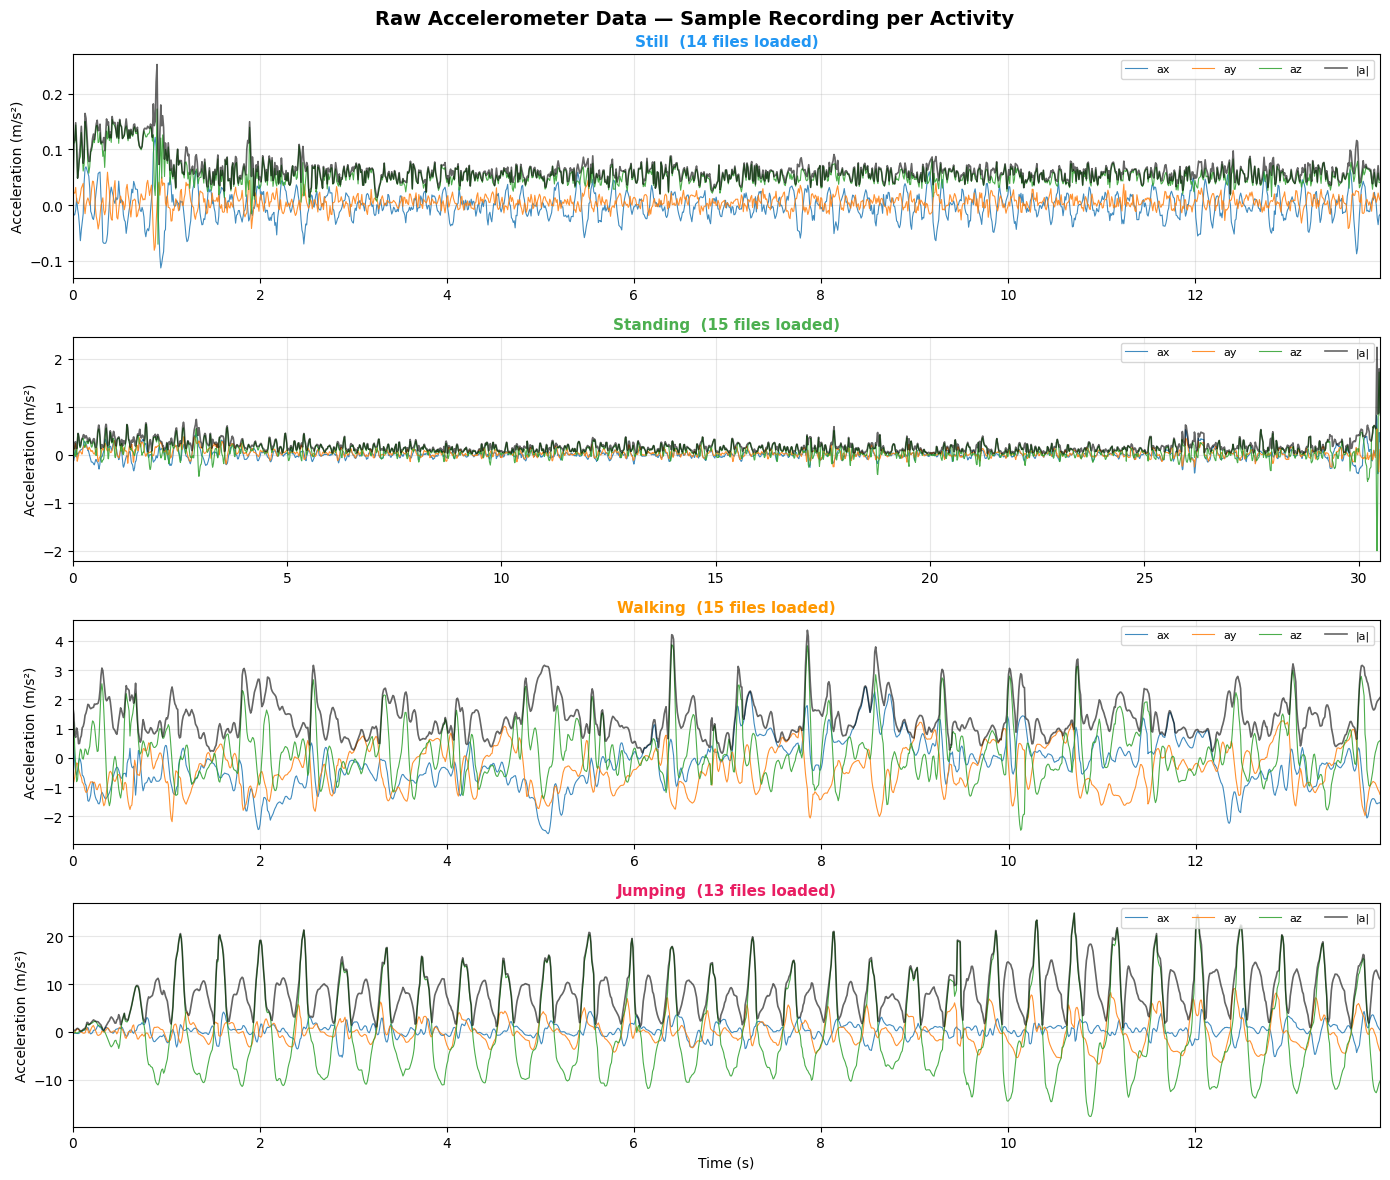

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Raw Accelerometer Data — Sample Recording per Activity', fontsize=14, fontweight='bold')

for ax, activity, color in zip(axes, ACTIVITIES, COLORS):
    if not raw_data[activity]:
        ax.set_title(f'{activity} — NO DATA', color='red'); continue
    df = raw_data[activity][0]
    t  = df['time'] - df['time'].iloc[0]
    ax.plot(t, df['ax'], label='ax', lw=0.8, alpha=0.85)
    ax.plot(t, df['ay'], label='ay', lw=0.8, alpha=0.85)
    ax.plot(t, df['az'], label='az', lw=0.8, alpha=0.85)
    ax.plot(t, df['aT'], label='|a|', color='black', lw=1.2, alpha=0.6)
    ax.set_title(f'{activity}  ({len(raw_data[activity])} files loaded)', fontsize=11, color=color, fontweight='bold')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.grid(alpha=0.3); ax.set_xlim(0, t.max())

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('raw_data_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 6 — Preprocessing (Low-Pass Filter)

In [28]:
def butter_lowpass(data, cutoff=20, fs=SAMPLING_RATE, order=4):
    b, a = signal.butter(order, cutoff/(fs/2), btype='low')
    return signal.filtfilt(b, a, data)

def preprocess(df):
    out = df.copy()
    for col in ['ax','ay','az','aT']: out[col] = butter_lowpass(df[col].values)
    return out

processed_data = {act: [preprocess(df) for df in dfs] for act, dfs in raw_data.items()}
print('Low-pass filter applied (cutoff = 20 Hz)')

Low-pass filter applied (cutoff = 20 Hz)


## STEP 7 — Windowing

**Window = 100 samples = 1 second** at 100 Hz captures ≥1 stride (walking ~1 Hz) and multiple jumps (~2–3 Hz).  
**50% overlap** doubles training samples without leakage.

In [29]:
def sliding_windows(df):
    data, wins = df[['ax','ay','az','aT']].values, []
    for s in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        wins.append(data[s:s+WINDOW_SIZE])
    return wins

windows_by_activity = {}
for activity, dfs in processed_data.items():
    wins = [w for df in dfs for w in sliding_windows(df)]
    windows_by_activity[activity] = wins
    print(f'  {activity:10s}: {len(wins):4d} windows  (from {len(dfs)} files)')

print(f'\nTotal windows: {sum(len(v) for v in windows_by_activity.values())}')

  Still     :  292 windows  (from 14 files)
  Standing  :  364 windows  (from 15 files)
  Walking   :  325 windows  (from 15 files)
  Jumping   :  292 windows  (from 13 files)

Total windows: 1273


## STEP 8 — Feature Extraction

| Domain | Feature | Why it helps distinguish activities |
|---|---|---|
| Time | Mean ax/ay/az/aT | Captures orientation & gravity component |
| Time | Std ax/ay/az/aT | Measures movement intensity |
| Time | RMS ax/ay/az/aT | Overall signal energy (high for jumping) |
| Time | SMA | Signal Magnitude Area — still vs active |
| Time | Axis correlations | Coordinated limb movement |
| Frequency | Dominant frequency | Walking ~2 Hz, Jumping ~3 Hz, Still ~0 Hz |
| Frequency | Spectral energy | High-intensity motion detection |

In [30]:
def extract_features(window):
    ax, ay, az, aT = window[:,0], window[:,1], window[:,2], window[:,3]
    feats = []
    for sig in [ax, ay, az, aT]:
        feats += [np.mean(sig), np.std(sig), np.sqrt(np.mean(sig**2))]
    feats.append(np.mean(np.abs(ax)) + np.mean(np.abs(ay)) + np.mean(np.abs(az)))
    feats += [np.corrcoef(ax,ay)[0,1], np.corrcoef(ax,az)[0,1], np.corrcoef(ay,az)[0,1]]
    for sig in [ax, ay, az, aT]:
        N = len(sig)
        mags = np.abs(fft(sig))[:N//2]
        pos_f = fftfreq(N, d=1.0/SAMPLING_RATE)[:N//2]
        dom = np.argmax(mags[1:]) + 1
        feats += [pos_f[dom], np.sum(mags**2)/N]
    return np.array(feats, dtype=np.float32)

FEATURE_NAMES = (
    [f'{s}_{c}' for c in ['ax','ay','az','aT'] for s in ['mean','std','rms']]
    + ['sma','corr_xy','corr_xz','corr_yz']
    + [f'{f}_{c}' for c in ['ax','ay','az','aT'] for f in ['dom_freq','spec_energy']]
)
print(f'Feature vector length: {len(extract_features(windows_by_activity["Walking"][0]))}')

Feature vector length: 24


## STEP 9 — Train / Test Split

In [31]:
train_sequences, test_sequences = [], []

for activity, dfs in processed_data.items():
    label   = STATE_MAP[activity]
    n_test  = min(TEST_FILES, max(1, len(dfs)//4))
    tr_dfs  = dfs[:-n_test]
    te_dfs  = dfs[-n_test:]

    for split_dfs, seq_list in [(tr_dfs, train_sequences), (te_dfs, test_sequences)]:
        for df in split_dfs:
            wins = sliding_windows(df)
            if wins:
                feats = np.nan_to_num(np.array([extract_features(w) for w in wins]))
                seq_list.append((feats, np.full(len(feats), label), activity))

    print(f'  {activity:10s}: {len(tr_dfs)} train | {len(te_dfs)} test files')

# Fit scaler on training data only
X_tr_all = np.vstack([s for s,_,_ in train_sequences])
scaler   = StandardScaler().fit(X_tr_all)

train_norm = [(scaler.transform(s), l, a) for s,l,a in train_sequences]
test_norm  = [(scaler.transform(s), l, a) for s,l,a in test_sequences]

print(f'\nTraining windows : {len(X_tr_all)}')
print(f'Test windows     : {sum(len(s) for s,_,_ in test_sequences)}')

  Still     : 12 train | 2 test files
  Standing  : 13 train | 2 test files
  Walking   : 13 train | 2 test files
  Jumping   : 11 train | 2 test files

Training windows : 1121
Test windows     : 152


## STEP 10 — HMM Implementation from Scratch

In [32]:
class GaussianHMM:
    """Hidden Markov Model with diagonal Gaussian emissions."""

    def __init__(self, n_states=4, n_iter=100, tol=1e-4):
        self.n_states = n_states
        self.n_iter   = n_iter
        self.tol      = tol

    def _init_params(self, X, y):
        S, D = self.n_states, X.shape[1]
        self.pi     = np.ones(S) / S
        self.means  = np.zeros((S, D))
        self.covars = np.ones((S, D))
        for s in range(S):
            mask = (y == s)
            if mask.sum() > 0:
                self.means[s]  = X[mask].mean(axis=0)
                self.covars[s] = X[mask].var(axis=0) + 1e-6
        self.A = np.full((S, S), 0.05/(S-1))
        np.fill_diagonal(self.A, 0.95)
        self.A /= self.A.sum(axis=1, keepdims=True)

    def _log_emission(self, x):
        log_p = np.zeros(self.n_states)
        for s in range(self.n_states):
            d = x - self.means[s]
            log_p[s] = -0.5 * np.sum(np.log(2*np.pi*self.covars[s]) + d**2/self.covars[s])
        return log_p

    def _emission_matrix(self, X):
        return np.array([self._log_emission(x) for x in X])

    def _forward(self, log_B):
        T, S = log_B.shape
        la = np.full((T, S), -np.inf)
        la[0] = np.log(self.pi + 1e-300) + log_B[0]
        log_A = np.log(self.A + 1e-300)
        for t in range(1, T):
            for s in range(S):
                la[t, s] = np.logaddexp.reduce(la[t-1] + log_A[:,s]) + log_B[t,s]
        return la

    def _backward(self, log_B):
        T, S = log_B.shape
        lb = np.full((T, S), -np.inf)
        lb[-1] = 0.0
        log_A = np.log(self.A + 1e-300)
        for t in range(T-2, -1, -1):
            for s in range(S):
                lb[t, s] = np.logaddexp.reduce(log_A[s,:] + log_B[t+1,:] + lb[t+1,:])
        return lb

    def fit(self, sequences_labels):
        """
        Baum-Welch training.
        sequences_labels: list of (X array, labels array, activity_name)
        Stops when |delta log-likelihood| < tol (convergence check).
        """
        X_all = np.vstack([s for s,_,_ in sequences_labels])
        y_all = np.concatenate([l for _,l,_ in sequences_labels])
        self._init_params(X_all, y_all)
        S, prev_ll = self.n_states, -np.inf
        self.log_likelihoods_ = []

        for it in range(self.n_iter):
            A_num = np.zeros((S,S))
            pi_num = mean_num = covar_num = gamma_sum = None
            pi_num    = np.zeros(S)
            mean_num  = np.zeros_like(self.means)
            covar_num = np.zeros_like(self.covars)
            gamma_sum = np.zeros(S)
            total_ll  = 0.0

            for X, _, _ in sequences_labels:
                log_B = self._emission_matrix(X)
                la    = self._forward(log_B)
                lb    = self._backward(log_B)
                log_A = np.log(self.A + 1e-300)
                log_px = np.logaddexp.reduce(la[-1])
                total_ll += log_px

                log_gamma = la + lb
                log_gamma -= np.logaddexp.reduce(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)

                T = len(X)
                for t in range(T-1):
                    xi = la[t,:,None] + log_A + log_B[t+1,None,:] + lb[t+1,None,:] - log_px
                    A_num += np.exp(xi)

                pi_num    += gamma[0]
                gamma_sum += gamma.sum(axis=0)
                for s in range(S):
                    mean_num[s]  += (gamma[:,s,None] * X).sum(axis=0)
                    diff = X - self.means[s]
                    covar_num[s] += (gamma[:,s,None] * diff**2).sum(axis=0)

            # M-step
            self.pi = pi_num / pi_num.sum()
            self.A  = A_num  / A_num.sum(axis=1, keepdims=True)
            for s in range(S):
                if gamma_sum[s] > 1e-8:
                    self.means[s]  = mean_num[s]  / gamma_sum[s]
                    self.covars[s] = covar_num[s] / gamma_sum[s] + 1e-6

            self.log_likelihoods_.append(total_ll)
            delta = abs(total_ll - prev_ll)
            if (it+1) % 10 == 0:
                print(f'  Iter {it+1:3d} | LL = {total_ll:.4f} | delta = {delta:.6f}')
            if delta < self.tol and it > 0:
                print(f'\nConverged at iteration {it+1}  (delta={delta:.2e} < tol={self.tol})')
                break
            prev_ll = total_ll
        else:
            print(f'Max iterations ({self.n_iter}) reached')
        return self

    def predict(self, X):
        """Viterbi decoding — returns most likely state sequence."""
        T, S  = len(X), self.n_states
        log_B = self._emission_matrix(X)
        log_A = np.log(self.A + 1e-300)
        delta = np.full((T,S), -np.inf)
        psi   = np.zeros((T,S), dtype=int)
        delta[0] = np.log(self.pi + 1e-300) + log_B[0]
        for t in range(1, T):
            for s in range(S):
                sc = delta[t-1] + log_A[:,s]
                psi[t,s] = np.argmax(sc)
                delta[t,s] = sc[psi[t,s]] + log_B[t,s]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path

print('GaussianHMM class ready')

GaussianHMM class ready


## STEP 11 — Train the Model (Baum-Welch)

In [33]:
print(f'Training on {len(train_norm)} sequences...')
hmm = GaussianHMM(n_states=N_STATES, n_iter=N_ITER, tol=CONV_THRESH)
hmm.fit(train_norm)

Training on 49 sequences...
  Iter  10 | LL = -8008.4295 | delta = 0.166648

Converged at iteration 14  (delta=8.84e-05 < tol=0.0001)


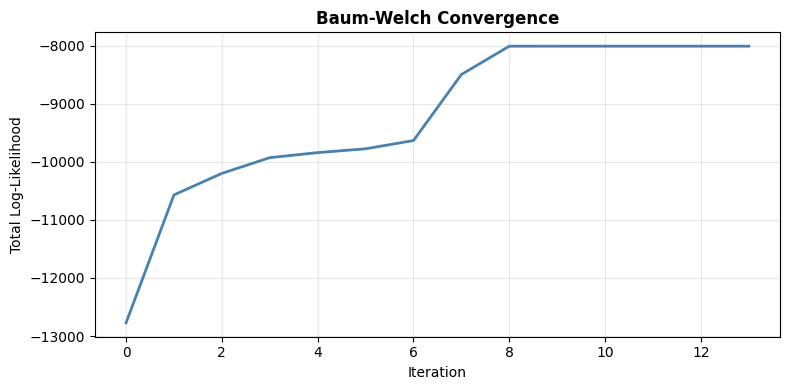

In [34]:
plt.figure(figsize=(8,4))
plt.plot(hmm.log_likelihoods_, color='steelblue', lw=2)
plt.xlabel('Iteration'); plt.ylabel('Total Log-Likelihood')
plt.title('Baum-Welch Convergence', fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 12 — Visualise Learned Model Parameters

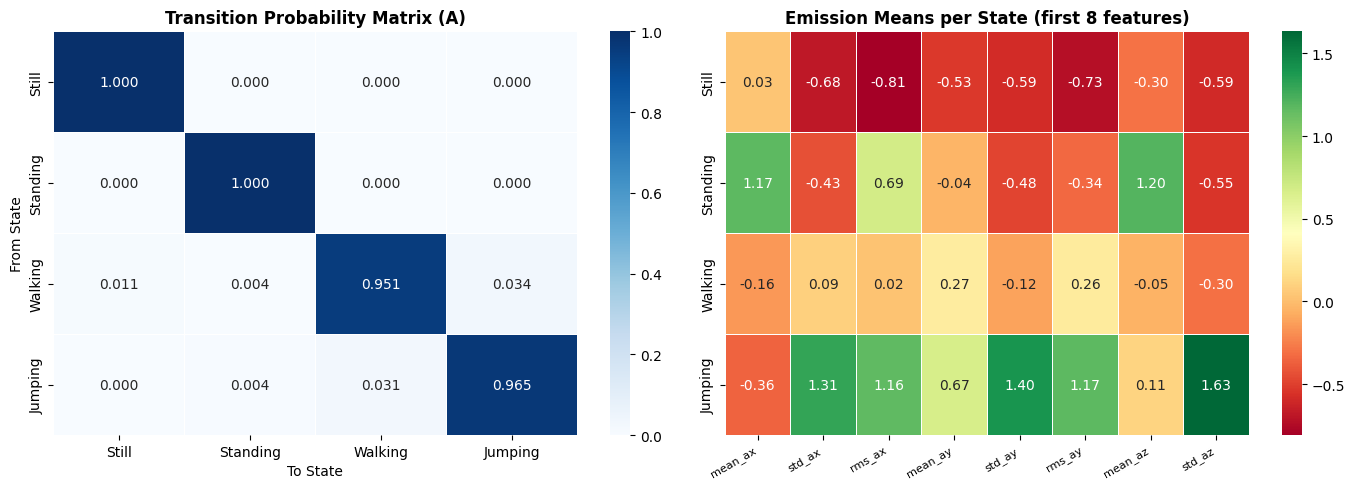


Transition Matrix:
           Still  Standing  Walking  Jumping
Still     1.0000    0.0000   0.0000   0.0000
Standing  0.0000    1.0000   0.0000   0.0000
Walking   0.0108    0.0036   0.9513   0.0343
Jumping   0.0000    0.0040   0.0307   0.9653


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            ax=axes[0], linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('Transition Probability Matrix (A)', fontweight='bold')
axes[0].set_xlabel('To State'); axes[0].set_ylabel('From State')

n_show = 8
sns.heatmap(pd.DataFrame(hmm.means[:,:n_show], index=ACTIVITIES, columns=FEATURE_NAMES[:n_show]),
            annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], linewidths=0.5)
axes[1].set_title('Emission Means per State (first 8 features)', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('model_parameters.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTransition Matrix:')
print(pd.DataFrame(hmm.A, index=ACTIVITIES, columns=ACTIVITIES).round(4))

## STEP 13 — Viterbi Decoding on Test Data

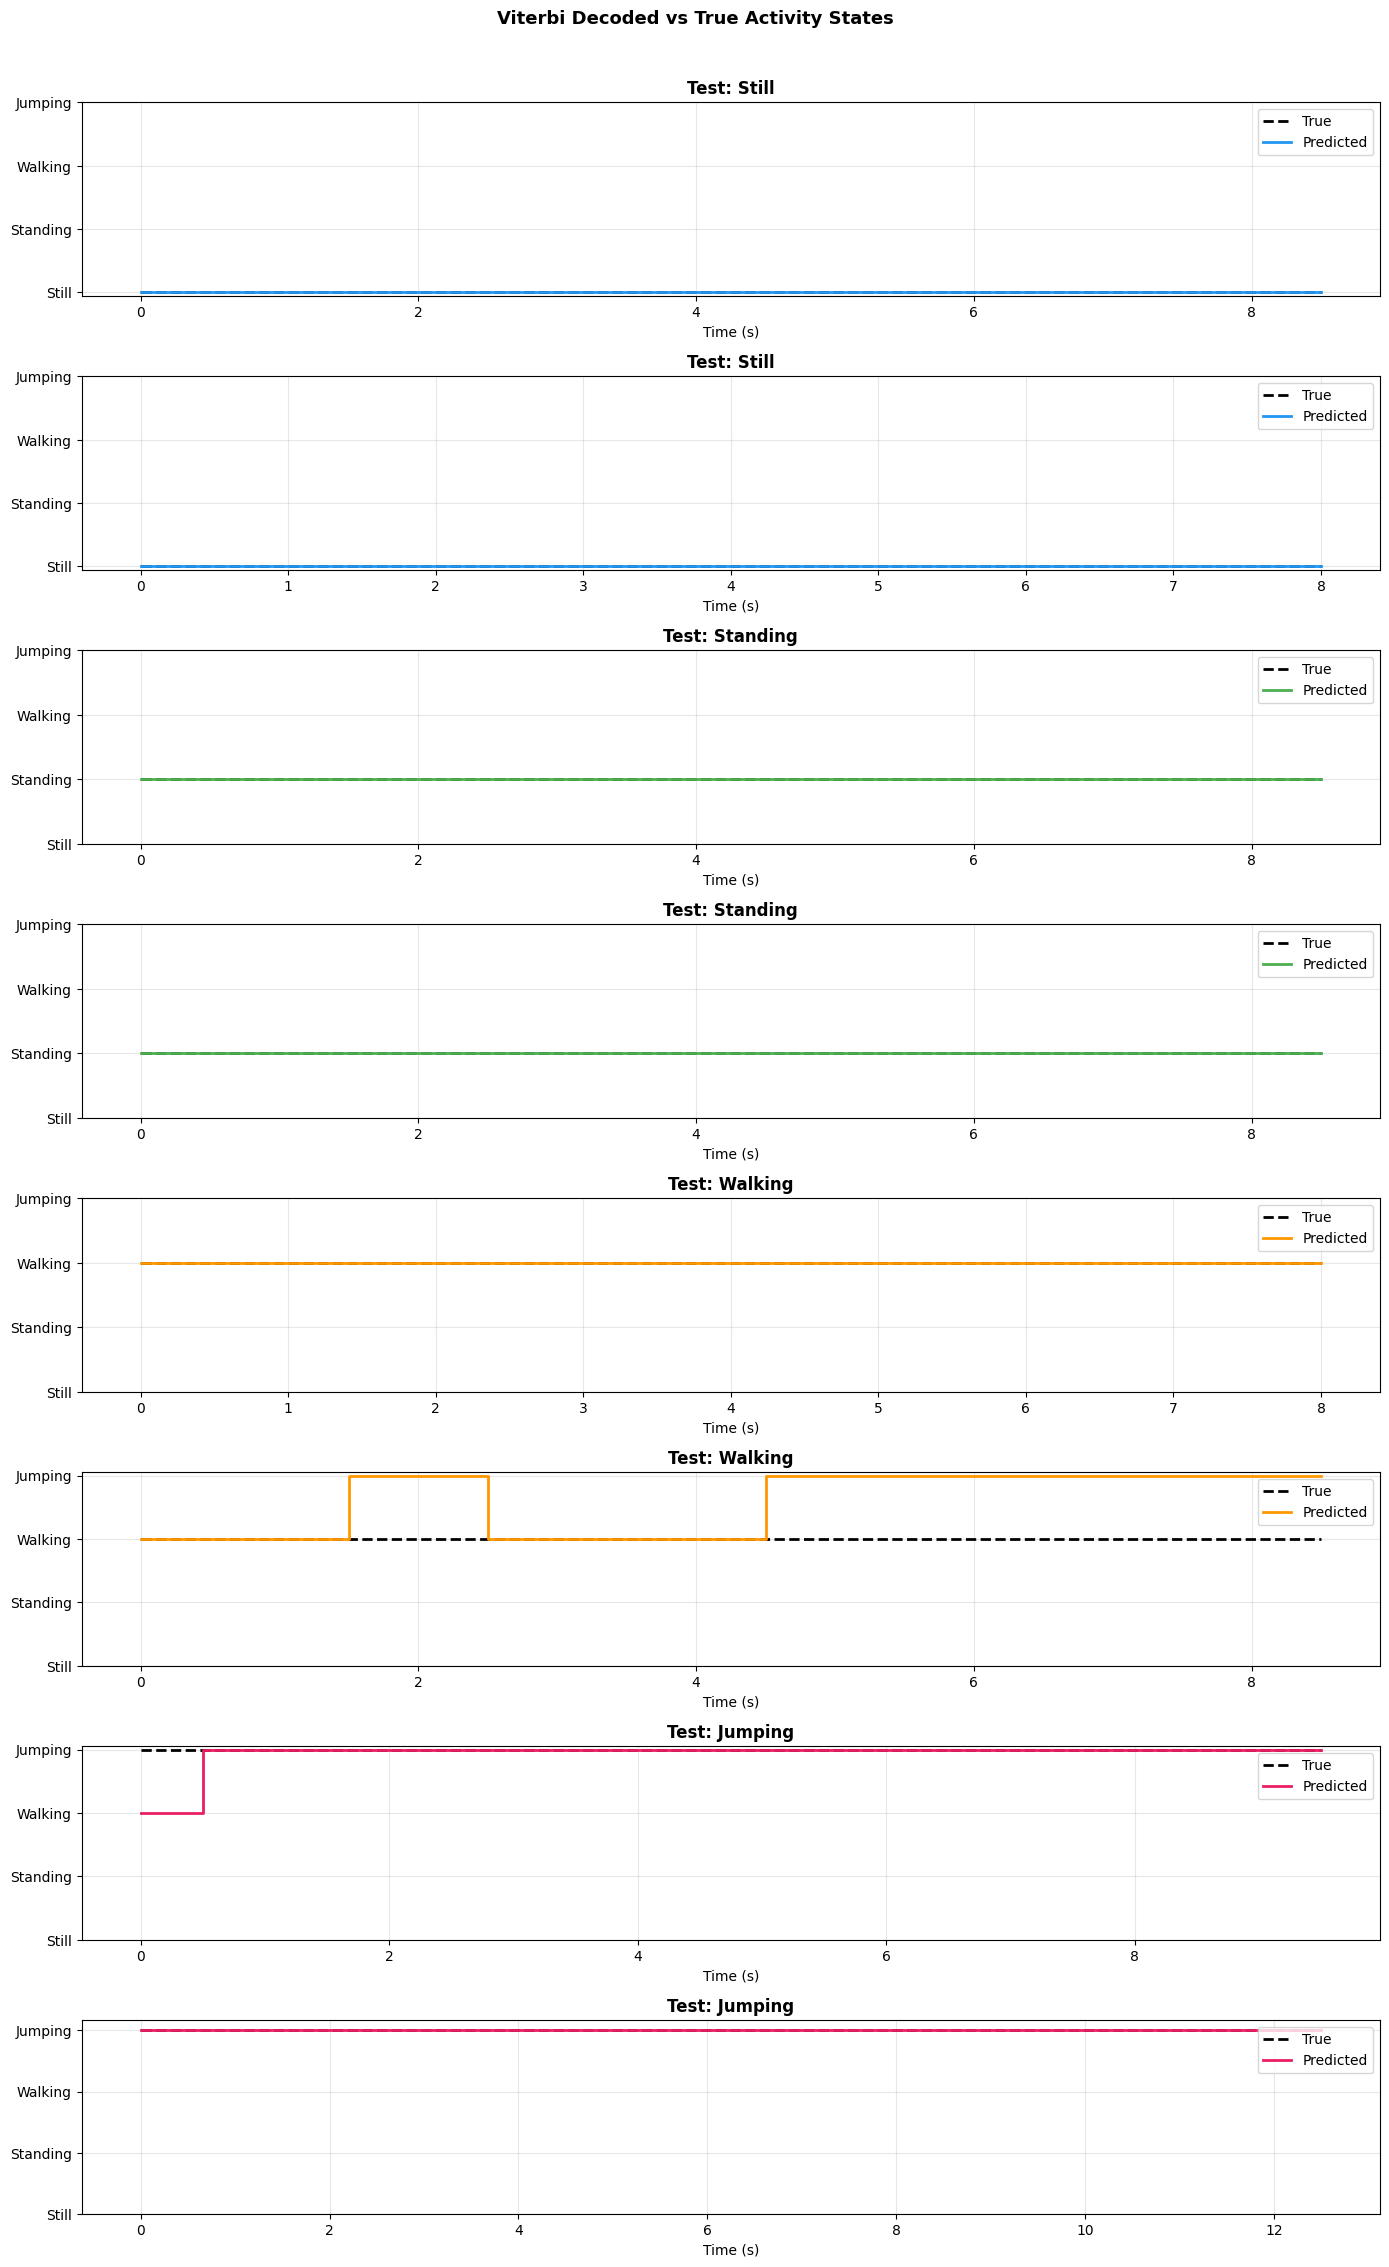

In [36]:
y_true_all, y_pred_all = [], []

fig, axes = plt.subplots(len(test_norm), 1, figsize=(14, 2.8*len(test_norm)), sharex=False)
if len(test_norm) == 1: axes = [axes]

for ax, (feats, true_lbl, activity) in zip(axes, test_norm):
    predicted = hmm.predict(feats)
    y_true_all.extend(true_lbl); y_pred_all.extend(predicted)
    t = np.arange(len(predicted)) * (STEP_SIZE/SAMPLING_RATE)
    ax.step(t, true_lbl,  where='post', color='black', lw=2, ls='--', label='True')
    ax.step(t, predicted, where='post', color=COLORS[STATE_MAP[activity]], lw=2, label='Predicted')
    ax.set_yticks(range(N_STATES)); ax.set_yticklabels(ACTIVITIES)
    ax.set_title(f'Test: {activity}', fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.legend(loc='upper right'); ax.grid(alpha=0.3)

plt.suptitle('Viterbi Decoded vs True Activity States', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viterbi_decoding.png', dpi=150, bbox_inches='tight')
plt.show()

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

## STEP 14 — Evaluation: Confusion Matrix & Metrics

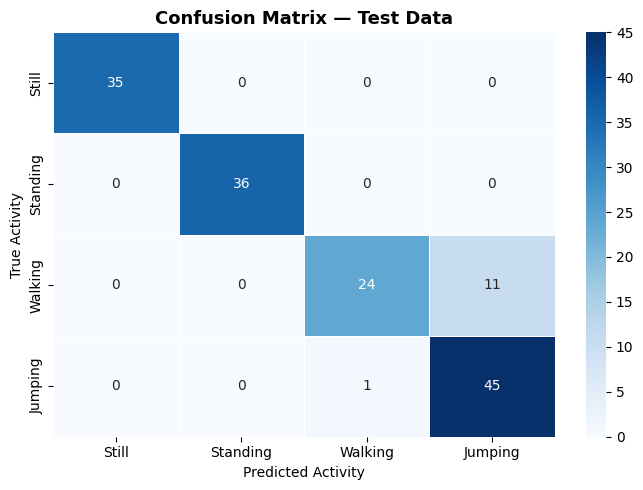

In [37]:
cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, linewidths=0.5)
plt.title('Confusion Matrix — Test Data', fontweight='bold', fontsize=13)
plt.xlabel('Predicted Activity'); plt.ylabel('True Activity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
results = []
for i, activity in enumerate(ACTIVITIES):
    TP = cm[i,i]; FN = cm[i,:].sum()-TP; FP = cm[:,i].sum()-TP; TN = cm.sum()-TP-FP-FN
    results.append({
        'Activity'   : activity,
        'N Samples'  : int(cm[i,:].sum()),
        'Sensitivity': round(TP/(TP+FN) if (TP+FN)>0 else 0, 4),
        'Specificity': round(TN/(TN+FP) if (TN+FP)>0 else 0, 4),
    })

overall_acc = accuracy_score(y_true_all, y_pred_all)
results_df  = pd.DataFrame(results)
results_df['Overall Accuracy'] = round(overall_acc, 4)

print('='*65)
print('EVALUATION RESULTS')
print('='*65)
print(results_df.to_string(index=False))
print(f'\nOverall Accuracy: {overall_acc*100:.2f}%')
print('\n' + classification_report(y_true_all, y_pred_all, target_names=ACTIVITIES))

EVALUATION RESULTS
Activity  N Samples  Sensitivity  Specificity  Overall Accuracy
   Still         35       1.0000       1.0000            0.9211
Standing         36       1.0000       1.0000            0.9211
 Walking         35       0.6857       0.9915            0.9211
 Jumping         46       0.9783       0.8962            0.9211

Overall Accuracy: 92.11%

              precision    recall  f1-score   support

       Still       1.00      1.00      1.00        35
    Standing       1.00      1.00      1.00        36
     Walking       0.96      0.69      0.80        35
     Jumping       0.80      0.98      0.88        46

    accuracy                           0.92       152
   macro avg       0.94      0.92      0.92       152
weighted avg       0.93      0.92      0.92       152



## STEP 15 — Feature Distribution Plots

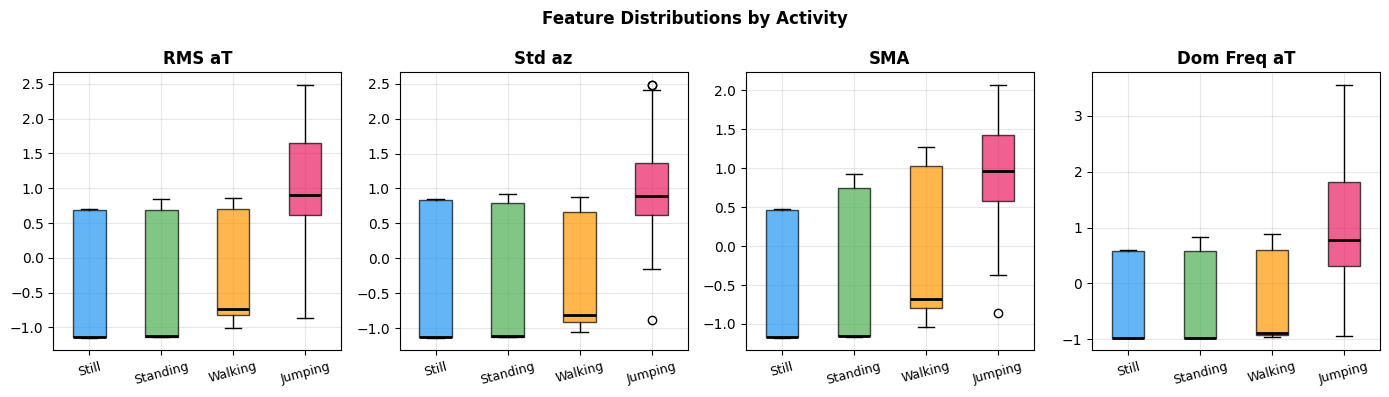

In [39]:
X_tr = scaler.transform(np.nan_to_num(np.array([
    extract_features(w)
    for act in ACTIVITIES
    for df in processed_data[act][:-TEST_FILES]
    for w in sliding_windows(df)
])))
y_tr = np.array([STATE_MAP[act] for act in ACTIVITIES
                 for df in processed_data[act][:-TEST_FILES]
                 for _ in sliding_windows(df)])

feat_idx = {'RMS aT': 11, 'Std az': 8, 'SMA': 12, 'Dom Freq aT': 23}
fig, axes = plt.subplots(1, len(feat_idx), figsize=(14,4))
for ax, (fname, fidx) in zip(axes, feat_idx.items()):
    bp = ax.boxplot([X_tr[y_tr==STATE_MAP[a], fidx] for a in ACTIVITIES],
                   patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(ACTIVITIES, rotation=15, fontsize=9)
    ax.set_title(fname, fontweight='bold'); ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions by Activity', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 16 — Download All Figures (Colab only)

In [ ]:
figures = ['raw_data_plot.png','convergence_plot.png','model_parameters.png',
           'viterbi_decoding.png','confusion_matrix.png','feature_distributions.png']

if IN_COLAB:
    from google.colab import files
    for f in figures:
        if os.path.exists(f):
            files.download(f)
            print(f'Downloading {f}')
else:
    print('Figures saved in current directory:')
    for f in figures: print(f'  {f}')

print(f'\nAll done! Final accuracy: {overall_acc*100:.2f}%')